TE density comparisons (10 Mb sliding windows) between Lsyl and Jeff. Boxplots per family per element type. Centromeric element proportion analysis.

In [1]:
import pybedtools
import pandas as pd
import os


```
bedtools makewindows -g data/local_patterns/Jeff_ref/chrom.sizes -w 10000000 -s 1000000 | awk 'BEGIN{OFS="\t"}{print $1,$2,$3,$1":"$2"-"$3}' > data/local_patterns/Jeff_bins_10Mb.bed
bedtools makewindows -g data/local_patterns/Lsyl/chrom.sizes -w 10000000 -s 1000000 | awk 'BEGIN{OFS="\t"}{print $1,$2,$3,$1":"$2"-"$3}' > data/local_patterns/Lsyl_bins_10Mb.bed
```

then summarize with workflow/scripts/count_tes_in_10mb_windows.sh

# Create histograms from counts

In [2]:

folders = ["data/local_patterns/Lsyl/TE_counts_by_window/",
           "data/local_patterns/Jeff/TE_counts_by_window/"]


In [3]:
df = pd.DataFrame()
for folder in folders:
    # file pattenrs folder + *_counts.bed
    species = folder.split("/")[2]
    for file in os.listdir(folder):
        if file.endswith("_counts.bed"):
            file_path = os.path.join(folder, file)
            temp_df = pd.read_csv(file_path, sep="\t", header=None,
                                  names=["start", "end", "bin", "count"])
            temp_df["element"] = file.replace("_counts.bed", "")
            temp_df["species"] = species
            df = pd.concat([df, temp_df], ignore_index=True)

df = df[df['element'].str.contains('|', regex=False)]
df['family'] = df['element'].str.split('|').str[-1]
df['element_type'] = df['element'].str.split('_').str[0]

df['count_per_mb'] = df['count'] / 10  # since windows are 10Mb

In [4]:
partial_df = df[df['element_type'] == 'partial']
full_df = df[df['element_type'] == 'full']
solo_df = df[df['element_type'] == 'solo']

In [5]:
# sum of counts for each family and element type split by species
summary_df = df.groupby(['species','element_type', 'family'])['count'].sum().reset_index()
print(summary_df)

   species element_type  family  count
0     Jeff         full     Ale    180
1     Jeff         full  Alesia    339
2     Jeff         full  Angela   1240
3     Jeff         full  Athila   1322
4     Jeff         full  Bianca    433
..     ...          ...     ...    ...
73    Lsyl         solo   Ivana   3586
74    Lsyl         solo    SIRE   4865
75    Lsyl         solo     TAR    454
76    Lsyl         solo   Tekay    335
77    Lsyl         solo    Tork   2097

[78 rows x 4 columns]


In [6]:
family_order = summary_df.groupby('family')['count'].sum().sort_values(ascending=False).index.tolist()

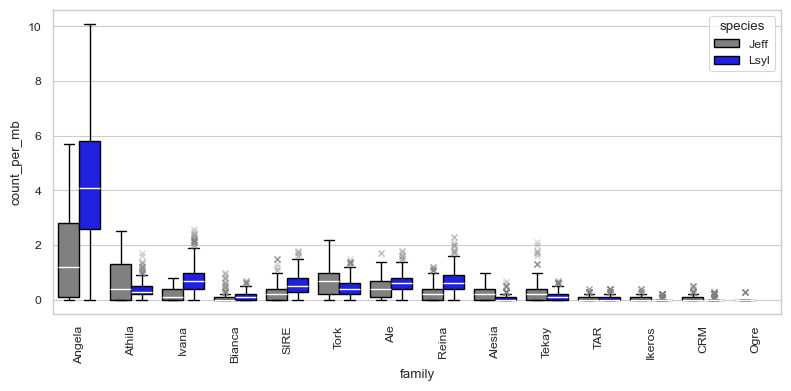

In [9]:
# boxplotfor  each family and element type split by species, ordered families by total count
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(context="paper", style="whitegrid")
palette = {"Lsyl": "#0000fff5", "Jeff": "gray"}
plt.figure(figsize=(8,4))
sns.boxplot(data=partial_df, x='family', y='count_per_mb', hue='species', order=family_order, palette=palette, hue_order=["Jeff", "Lsyl"], dodge=True,
            linewidth=1,  linecolor="black",
            flierprops=dict(marker='x', markersize=5, markeredgecolor='gray', alpha=0.3),
    whiskerprops=dict(color='black'), 
    capprops=dict(color='black'), 
    medianprops=dict(color='white'), 
    boxprops=dict(edgecolor='black')
)
# ticks rotation
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()



<Figure size 1800x500 with 0 Axes>

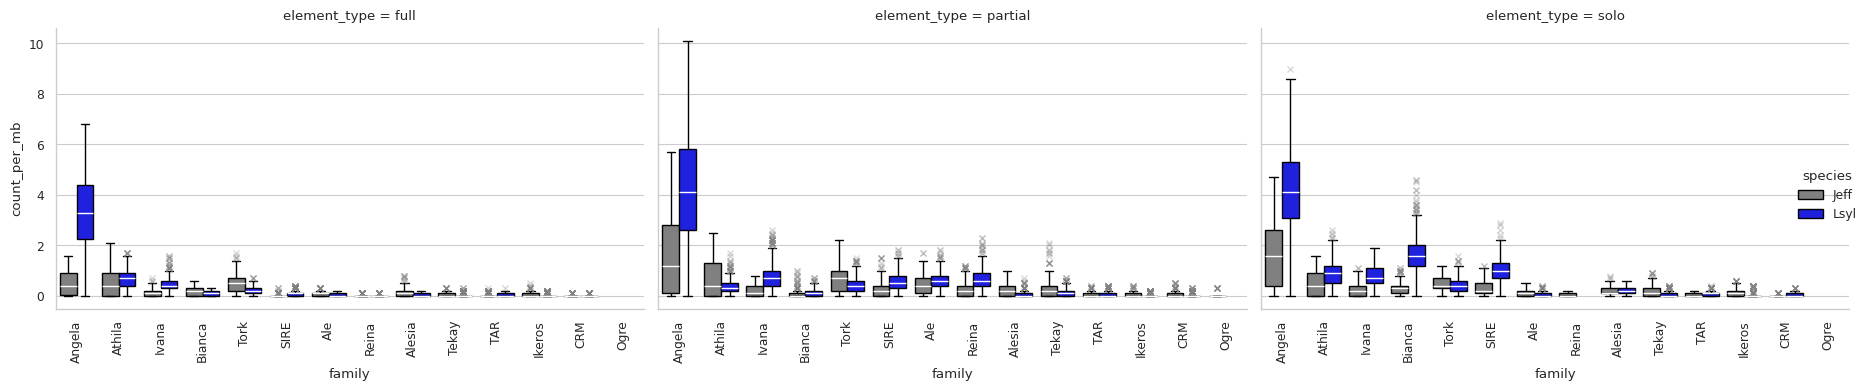

In [81]:
# facet full, partial, solo
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(context="paper", style="whitegrid")
plt.figure(figsize=(18,5))
palette = {"Lsyl": "#0000fff5", "Jeff": "gray"}
g = sns.catplot(data=df, x='family', y='count_per_mb', hue='species', order=family_order, palette=palette, hue_order=["Jeff", "Lsyl"], dodge=True,
            linewidth=1,  linecolor="black",
            flierprops=dict(marker='x', markersize=5, markeredgecolor='gray', alpha=0.3),
    whiskerprops=dict(color='black'), 
    capprops=dict(color='black'), 
    medianprops=dict(color='white'), 
    boxprops=dict(edgecolor='black'),
            col='element_type', kind='box', height=4, aspect=1.5, col_order=['full', 'partial', 'solo'])
# ticks rotation
for ax in g.axes.flat:
    for label in ax.get_xticklabels():
        label.set_rotation(90)
#plt.ylim(0, 8)
plt.tight_layout()
plt.show()                              

In [10]:
from matplotlib import font_manager
import matplotlib

# Add fonts from the new directory to matplotlib
custom_fonts_path = "config/fonts"
custom_fonts = font_manager.findSystemFonts(fontpaths=custom_fonts_path, fontext='ttf')
for font in custom_fonts:
    try:
        font_manager.fontManager.addfont(font)
    except Exception as e:
        print(f"Skipping font {font} due to error: {e}")


matplotlib.rcParams['font.family'] = "sans-serif"
matplotlib.rcParams['font.sans-serif'] = "Arial"

sorted(font_manager.get_font_names())

Skipping font /auto/brno12-cerit/nfs4/home/kratka/brno1/LTR-TE_dynamics/config/fonts/fonts/truetype/noto/NotoColorEmoji.ttf due to error: Can not load face (unknown file format; error code 0x2)


['Abyssinica SIL',
 'Ani',
 'AnjaliOldLipi',
 'Arial',
 'Arial Black',
 'Arial CE',
 'Arial CE MT Black',
 'Arial Light',
 'C059',
 'Chandas',
 'Chilanka',
 'Classic Console',
 'D050000L',
 'DejaVu Math TeX Gyre',
 'DejaVu Sans',
 'DejaVu Sans Display',
 'DejaVu Sans Mono',
 'DejaVu Serif',
 'DejaVu Serif Display',
 'Dhurjati',
 'Droid Sans Fallback',
 'Dyuthi',
 'FreeMono',
 'FreeSans',
 'FreeSerif',
 'Gargi',
 'Garuda',
 'Gayathri',
 'Gidugu',
 'Gubbi',
 'Gurajada',
 'Jamrul',
 'KacstArt',
 'KacstBook',
 'KacstDecorative',
 'KacstDigital',
 'KacstFarsi',
 'KacstLetter',
 'KacstNaskh',
 'KacstOffice',
 'KacstOne',
 'KacstPen',
 'KacstPoster',
 'KacstQurn',
 'KacstScreen',
 'KacstTitle',
 'KacstTitleL',
 'Kalapi',
 'Kalimati',
 'Karumbi',
 'Keraleeyam',
 'Khmer OS',
 'Khmer OS System',
 'Kinnari',
 'LKLUG',
 'LakkiReddy',
 'Laksaman',
 'Lato',
 'Liberation Mono',
 'Liberation Sans',
 'Liberation Sans Narrow',
 'Liberation Serif',
 'Likhan',
 'Lohit Assamese',
 'Lohit Bengali',
 'Lohit 

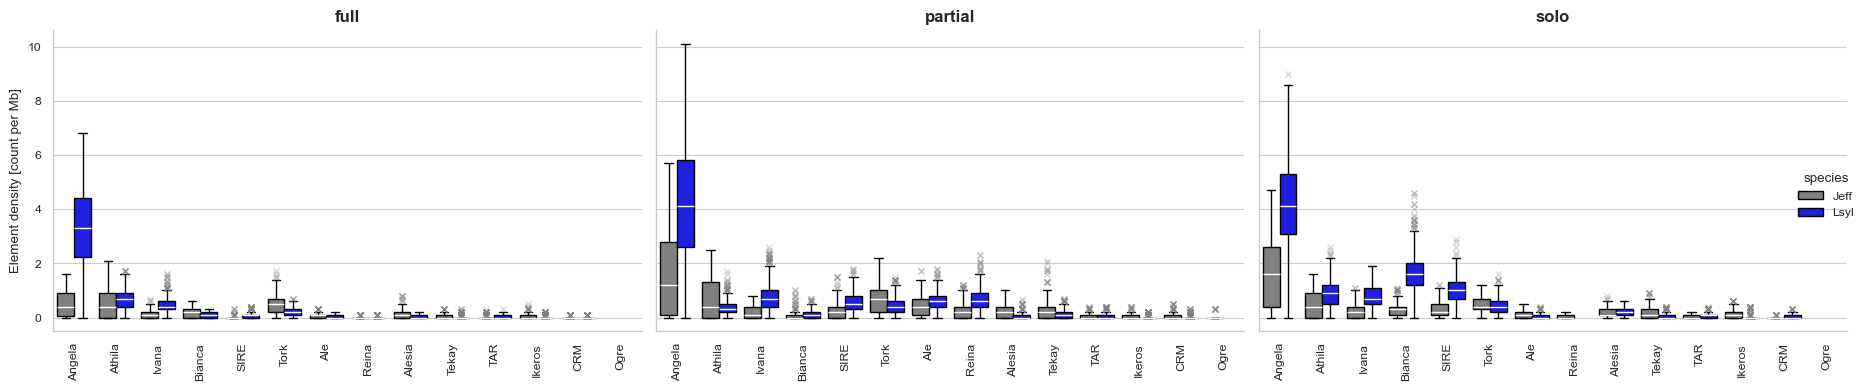

In [11]:
# facet full, partial, solo
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(context="paper", style="whitegrid")

palette = {"Lsyl": "#0000fff5", "Jeff": "gray"}
g = sns.catplot(data=df, x='family', y='count_per_mb', hue='species', 
                order=family_order, palette=palette, hue_order=["Jeff", "Lsyl"], 
                dodge=True, linewidth=1, linecolor="black",
                flierprops=dict(marker='x', markersize=5, markeredgecolor='gray', alpha=0.3),
                whiskerprops=dict(color='black'), 
                capprops=dict(color='black'), 
                medianprops=dict(color='white'), 
                boxprops=dict(edgecolor='black'),
                col='element_type', kind='box', height=4, aspect=1.5, 
                col_order=['full', 'partial', 'solo'])

# Set titles for each facet (capitalize first letter only)
g.set_titles("{col_name}", size=12, weight='bold')

# Set axis labels
g.set_axis_labels("", "Element density [count per Mb]")

# Rotate x-axis labels
for ax in g.axes.flat:
    for label in ax.get_xticklabels():
        label.set_rotation(90)

plt.tight_layout()
plt.savefig("data/figures/element_density_Lsyl_Jeff_boxplot.svg", dpi=300)
plt.show()

# Centromeric elements
stacked barplot of the proporiton of centromeric elements of individual families

In [12]:
species = ["Jeff", "Lsyl"]
position = ["centromeric", "noncentromeric"]

centromeric_df = pd.DataFrame()

for sp in species:
    for pos in position:
        path = f"data/local_patterns/{sp}/full_{pos}.gff3"
        temp_df = pd.read_csv(path, sep="\t", header=None,
                              names=["chrom", "source", "feature", "start", "end", "score", "strand", "phase", "attributes"])
        temp_df['species'] = sp
        temp_df['position'] = pos
        centromeric_df = pd.concat([centromeric_df, temp_df], ignore_index=True)

centromeric_df['family'] = centromeric_df['attributes'].str.extract(r'Class=([^;]+)').iloc[:, 0].str.split('|').str[-1]
        

In [13]:
centromere_summary = centromeric_df.groupby(['species', 'position', 'family']).size().reset_index(name='count')
print(centromere_summary)

   species        position  family  count
0     Jeff     centromeric  Angela      8
1     Jeff     centromeric  Athila     46
2     Jeff     centromeric  Bianca      1
3     Jeff     centromeric  Ikeros      1
4     Jeff     centromeric   Tekay      1
5     Jeff     centromeric    Tork      2
6     Jeff  noncentromeric     Ale     31
7     Jeff  noncentromeric  Alesia     59
8     Jeff  noncentromeric  Angela    203
9     Jeff  noncentromeric  Athila    174
10    Jeff  noncentromeric  Bianca     75
11    Jeff  noncentromeric     CRM      2
12    Jeff  noncentromeric  Ikeros     14
13    Jeff  noncentromeric   Ivana     65
14    Jeff  noncentromeric   Reina      3
15    Jeff  noncentromeric    SIRE      9
16    Jeff  noncentromeric     TAR     12
17    Jeff  noncentromeric   Tekay     23
18    Jeff  noncentromeric    Tork    206
19    Lsyl     centromeric  Angela     32
20    Lsyl     centromeric  Athila     72
21    Lsyl     centromeric   Ivana      2
22    Lsyl     centromeric    SIRE

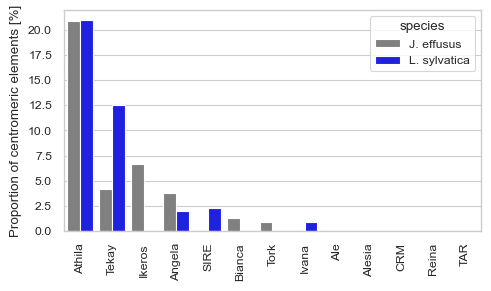

In [ ]:
# barplot of the proporiton of centromeric elements of individual families with text labels showing the absolute value
import seaborn as sns
import matplotlib.pyplot as plt

centromere_pivot = centromere_summary.pivot_table(index=['species', 'family'], columns='position', values='count', fill_value=0).reset_index()
centromere_pivot['total'] = centromere_pivot['centromeric'] + centromere_pivot['noncentromeric']
centromere_pivot['centromeric_pct'] = centromere_pivot['centromeric'] / centromere_pivot['total'] * 100             
centromere_pivot = centromere_pivot.sort_values(by='centromeric_pct', ascending=False)

# save centromere_pivot to csv
centromere_pivot.to_csv("data/tables/centromeric_element_proportion_Lsyl_Jeff.csv", index=False)

# create label column
centromere_pivot['label'] = centromere_pivot['centromeric'].astype(int).astype(str) + "/" + centromere_pivot['total'].astype(int).astype(str)

# change species name to full name
centromere_pivot['species'] = centromere_pivot['species'].replace({'Jeff': 'J. effusus', 'Lsyl': 'L. sylvatica'})
palette = {"L. sylvatica": "#0000fff5", "J. effusus": "gray"}

# order centromere_pivot by species and centromeric_pct (jeff first)
family_order = centromere_pivot.groupby('family')['centromeric_pct'].sum().sort_values(ascending=False).index.tolist()
species_order = ["J. effusus", "L. sylvatica"]


plt.figure(figsize=(5,3))
sns.barplot(data=centromere_pivot, x='family', y='centromeric_pct', hue='species', palette=palette, hue_order=["J. effusus", "L. sylvatica"])
plt.xticks(rotation=90)
plt.xlabel("")
plt.ylabel("Proportion of centromeric elements [%]")
plt.tight_layout()
plt.savefig("data/figures/centromeric_element_proportion_Lsyl_Jeff.svg", dpi=300)
plt.show()

                                   

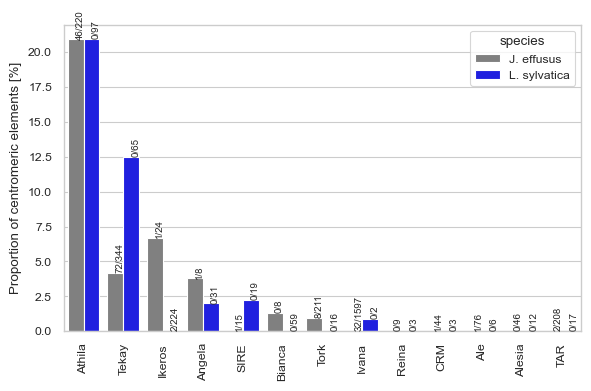

In [41]:
# barplot of the proportion of centromeric elements of individual families with text labels showing the absolute value
import seaborn as sns
import matplotlib.pyplot as plt

centromere_pivot = centromere_summary.pivot_table(index=['species', 'family'], columns='position', values='count', fill_value=0).reset_index()
centromere_pivot['total'] = centromere_pivot['centromeric'] + centromere_pivot['noncentromeric']
centromere_pivot['centromeric_pct'] = centromere_pivot['centromeric'] / centromere_pivot['total'] * 100             
centromere_pivot = centromere_pivot.sort_values(by='centromeric_pct', ascending=False)

# save centromere_pivot to csv
centromere_pivot.to_csv("data/tables/centromeric_element_proportion_Lsyl_Jeff.csv", index=False)

# create label column
centromere_pivot['label'] = centromere_pivot['centromeric'].astype(int).astype(str) + "/" + centromere_pivot['total'].astype(int).astype(str)

# change species name to full name
centromere_pivot['species'] = centromere_pivot['species'].replace({'Jeff': 'J. effusus', 'Lsyl': 'L. sylvatica'})
palette = {"L. sylvatica": "#0000fff5", "J. effusus": "gray"}

# order centromere_pivot by species and centromeric_pct (jeff first)
family_order = centromere_pivot.groupby('family')['centromeric_pct'].sum().sort_values(ascending=False).index.tolist()
species_order = ["J. effusus", "L. sylvatica"]

fig, ax = plt.subplots(figsize=(6,4))
sns.barplot(data=centromere_pivot, x='family', y='centromeric_pct', hue='species', 
            palette=palette, hue_order=species_order, ax=ax)

# Get unique families in the order they appear (sorted by total centromeric_pct)
families = family_order

# Add labels to bars

label_order = []
for i, bar in enumerate(ax.patches):
    # Determine which family and species this bar represents
    family_idx = i // len(species_order)  # Which family position
    species_idx = i % len(species_order)   # Which species (0=J. effusus, 1=L. sylvatica)
    
    if family_idx < len(families):
        family = families[family_idx]
        species = species_order[species_idx]
        
        # Get the corresponding row from the DataFrame
        row = centromere_pivot[(centromere_pivot['family'] == family) & 
                               (centromere_pivot['species'] == species)]
        
        if not row.empty:
            label = row['label'].iloc[0]
            label_order.append(label)
            height = bar.get_height()
            
            # Add text label above the bar
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    label,
                    ha='left', va='bottom', fontsize=7, rotation=90)

plt.xticks(rotation=90)
plt.xlabel("")
plt.ylabel("Proportion of centromeric elements [%]")
plt.tight_layout()
plt.savefig("data/figures/centromeric_element_proportion_Lsyl_Jeff.svg", dpi=300)
plt.show()

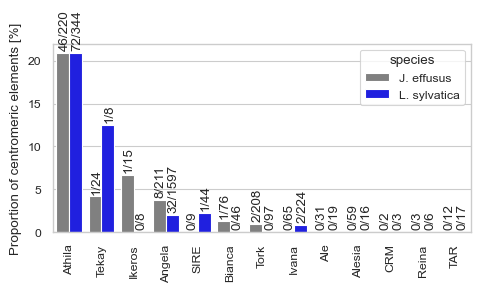

In [52]:
# barplot of the proportion of centromeric elements of individual families with text labels showing the absolute value
import seaborn as sns
import matplotlib.pyplot as plt

centromere_pivot = centromere_summary.pivot_table(index=['species', 'family'], columns='position', values='count', fill_value=0).reset_index()
centromere_pivot['total'] = centromere_pivot['centromeric'] + centromere_pivot['noncentromeric']
centromere_pivot['centromeric_pct'] = centromere_pivot['centromeric'] / centromere_pivot['total'] * 100             
centromere_pivot = centromere_pivot.sort_values(by='centromeric_pct', ascending=False)

# save centromere_pivot to csv
centromere_pivot.to_csv("data/tables/centromeric_element_proportion_Lsyl_Jeff.csv", index=False)

# create label column
centromere_pivot['label'] = centromere_pivot['centromeric'].astype(int).astype(str) + "/" + centromere_pivot['total'].astype(int).astype(str)

# change species name to full name
centromere_pivot['species'] = centromere_pivot['species'].replace({'Jeff': 'J. effusus', 'Lsyl': 'L. sylvatica'})
palette = {"L. sylvatica": "#0000fff5", "J. effusus": "gray"}

# order centromere_pivot by species and centromeric_pct (jeff first)
family_order = centromere_pivot.groupby('family')['centromeric_pct'].sum().sort_values(ascending=False).index.tolist()
species_order = ["J. effusus", "L. sylvatica"]

fig, ax = plt.subplots(figsize=(5,3))
sns.barplot(data=centromere_pivot, x='family', y='centromeric_pct', hue='species', 
            palette=palette, hue_order=species_order, order=family_order, ax=ax)

# Add labels to bars
# Bars are ordered: all J. effusus bars first, then all L. sylvatica bars
num_families = len(family_order)

for i, bar in enumerate(ax.patches):
    # Calculate family index and species index
    family_idx = i % num_families
    species_idx = i // num_families

    # Ensure species_idx is within bounds
    if species_idx >= len(species_order):
        continue

    species = species_order[species_idx]
    family = family_order[family_idx]

    # Get the corresponding row from the DataFrame
    row = centromere_pivot[(centromere_pivot['family'] == family) & 
                           (centromere_pivot['species'] == species)]
    
    if not row.empty:
        label = row['label'].iloc[0]
        height = bar.get_height()
        
        # Add text label above the bar
        ax.text(bar.get_x() + bar.get_width()/2. + 0.05, height + 0.3,
                label,
                ha='center', va='bottom', rotation=90)

plt.xticks(rotation=90)
plt.xlabel("")
plt.ylabel("Proportion of centromeric elements [%]")
plt.tight_layout()
plt.savefig("data/figures/centromeric_element_proportion_Lsyl_Jeff.svg", dpi=300)
plt.show()